# Docking with cmxflow: blind, constrained, and scaffold-indexed

This notebook showcases the `cmxflow.operators.dock` subpackage on a kinase
target (ABL1 from DUD-E), using a **congeneric series** built around the co-crystallized
ligand. Three docking modes are demonstrated, all on the *same* set of molecules
and all running in parallel:

| Section | Mode | What it shows |
|---|---|---|
| **(a)** | **Blind docking** | Dock unaligned conformers; the block recenters on the reference pocket automatically. Iterated local search (ILS) finds lower-energy poses. |
| **(b)** | **Scaffold-indexed docking** | Index unique scaffolds across docking runs giving consistent poses and a significant speed up. |

All timings are measured live, and the final docked poses are written to SDF for review.

In [1]:
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import Draw

from cmxflow import Workflow
from cmxflow.operators import (
    ConformerGenerationBlock,
    MoleculeDockBlock,
)
from cmxflow.sinks import MoleculeSinkBlock
from cmxflow.sources import MoleculeSourceBlock, read_molecules
from cmxflow.utils.parallel import make_parallel
from cmxflow.scores import mol_to_dataframe


RECEPTOR = Path("../receptor.pdb")
REFERENCE = Path("../crystal_ligand.sdf")
LIBRARY = Path("library.csv")

## The system and a congeneric series

The ABL1 reference ligand is a pyrimidine-fused pyridinone kinase inhibitor. Its
Bemis–Murcko scaffold (the fused bicyclic hinge-binder plus the two pendant aryl
rings) is what defines the series: every substituent we vary below sits off
those ring systems on the two phenyls or the lactam nitrogen.

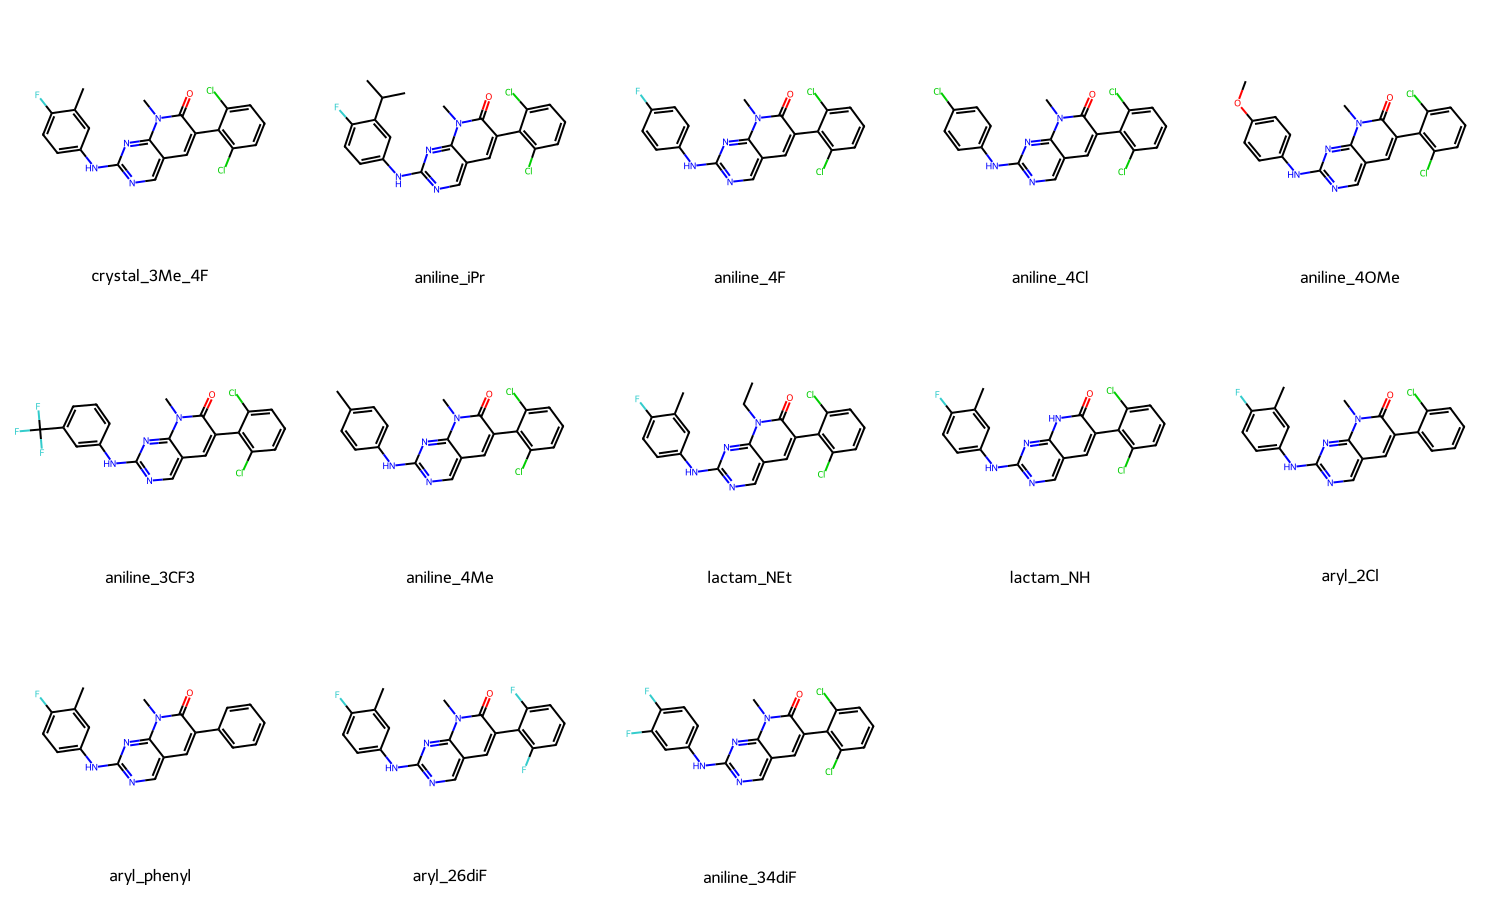

In [2]:
mols = list(read_molecules(LIBRARY))
Draw.MolsToGridImage(
    mols,
    legends=[mol.GetProp("ID") for mol in mols],
    subImgSize=(300,300),
    molsPerRow=5,
)

## (a) Blind docking with automatic pocket recentering

The conformers in the following workflow are **not** positioned in the
binding site. Because we pass a `site_reference`, the dock block anchors its
search box on the reference ligand's centroid and seeds restarts with fresh
distance-geometry conformers placed in the pocket. So a raw conformer is enough;
no manual alignment step is required.

In [3]:
workflow = Workflow()
workflow.add(
    MoleculeSourceBlock(),
    ConformerGenerationBlock(),
    make_parallel(
        MoleculeDockBlock(receptor=RECEPTOR, site_reference=REFERENCE)
    ),
    MoleculeSinkBlock()
)


                               ┌────────────────┐                                
                               │ MoleculeSource │                                
                               ├────────────────┤                                
                               │ input: [FILE]  │                                
                               └────────────────┘                                
                                       ↓                                         
                          ┌──────────────────────────┐                           
                          │   ConformerGeneration    │                           
                          ├──────────────────────────┤                           
                          │ numConfs: 1              │                           
                          │ pruneRmsThresh: 1.500000 │                           
                          │ useRandomCoords: False   │                           
               

In [4]:
%%time
workflow(LIBRARY, Path("docking_defaults.sdf"))

CPU times: user 321 ms, sys: 32.3 ms, total: 353 ms
Wall time: 15.5 s


### Better poses with iterated local search (ILS)

`basin_hops` turns on iterated local search: after each restart minimizes, the
pose is perturbed and re-minimized, letting it hop between nearby basins. It costs
more time but reliably finds lower-energy poses than the single-minimize default.

In [5]:
workflow = Workflow()
workflow.add(
    MoleculeSourceBlock(),
    ConformerGenerationBlock(),
    make_parallel(
        MoleculeDockBlock(
            receptor=RECEPTOR, 
            site_reference=REFERENCE, 
            basin_hops=5,
        )
    ),
    MoleculeSinkBlock()
)


                               ┌────────────────┐                                
                               │ MoleculeSource │                                
                               ├────────────────┤                                
                               │ input: [FILE]  │                                
                               └────────────────┘                                
                                       ↓                                         
                          ┌──────────────────────────┐                           
                          │   ConformerGeneration    │                           
                          ├──────────────────────────┤                           
                          │ numConfs: 1              │                           
                          │ pruneRmsThresh: 1.500000 │                           
                          │ useRandomCoords: False   │                           
               

In [6]:
%%time
workflow(LIBRARY, Path("docking_ILS.sdf"))

CPU times: user 310 ms, sys: 25.2 ms, total: 336 ms
Wall time: 46.7 s


## (b) Scaffold-indexed docking

With `index_poses=True` docking will index optimized poses for unique scaffolds:

- The dock block maintains a single-file cache at `./.cmxflow/scaffold_index.db`,
  keyed by Bemis–Murcko scaffold (and namespaced by the docking parameters).
- The **reference ligand's** scaffold pose is seeded first, so the whole series is
  a cache **hit** immediately: each congener transfers the cached core and runs a
  single constrained local search — no manual placement, no SMARTS.
- Cache writes are first-writer-wins (`INSERT OR IGNORE`), so it is safe across the
  parallel workers, and the cache persists across runs.

Each docked pose is tagged with a `docking_indexed` provenance flag.

In [7]:
workflow = Workflow()
workflow.add(
    MoleculeSourceBlock(),
    ConformerGenerationBlock(),
    make_parallel(
        MoleculeDockBlock(
            receptor=RECEPTOR, 
            site_reference=REFERENCE, 
            index_poses=True,
        )
    ),
    MoleculeSinkBlock()
)


                               ┌────────────────┐                                
                               │ MoleculeSource │                                
                               ├────────────────┤                                
                               │ input: [FILE]  │                                
                               └────────────────┘                                
                                       ↓                                         
                          ┌──────────────────────────┐                           
                          │   ConformerGeneration    │                           
                          ├──────────────────────────┤                           
                          │ numConfs: 1              │                           
                          │ pruneRmsThresh: 1.500000 │                           
                          │ useRandomCoords: False   │                           
               

In [8]:
%%time
workflow(LIBRARY, Path("docking_scaffold_indexed.sdf"))

CPU times: user 289 ms, sys: 26 ms, total: 315 ms
Wall time: 5.39 s


## Summary

In [9]:
for path in [
    "docking_defaults.sdf",
    "docking_ILS.sdf",
    "docking_scaffold_indexed.sdf",
]:
    df = mol_to_dataframe(read_molecules(Path(path)))
    print(
        path, 
        f"N={len(df)}", 
        f"MeanScore={df.docking_score.mean()}",
        f"MaxScore={df.docking_score.max()}",
    )

docking_defaults.sdf N=13 MeanScore=-11.724461746142122 MaxScore=-8.153862783666723
docking_ILS.sdf N=13 MeanScore=-11.913085437773363 MaxScore=-8.227326992550939
docking_scaffold_indexed.sdf N=13 MeanScore=-11.823206213537514 MaxScore=-9.08767926562904


In [10]:
# Clean up
!rm -r .cmxflow